# 🚀 Session 5 – Supervised Learning (Tree-Based Models)
## From **Orange** data mining (In AI Wizards) to **Python + Scikit-learn**

⏱ Estimated Time: 20 minutes

---

## 🌉 Bridging Orange Datamining to Python and Scikit-learn

In the **AI Wizards Program**, you learned Machine Learning using **Orange Data Mining** — a visual, drag-and-drop tool for building models.

Using Orange, you explored:

- Supervised Learning (Classification)
- Decision Trees (by hand and using widgets: Tree Widget)
- Training/Test split
- Cross-Validation
- Overfitting vs Generalization
- Random Forest ("Wisdom of the Majority")
- Manual parameter tuning
- Confusion Matrix interpretation

You already understand the **core machine learning concepts**.

Now, you shift to a more *powerful* and *industry-standard* approach:

> 💻 Instead of dragging widgets, you will write Python codes.  
> 🔬 Instead of manual tuning, you will automate optimization.  
> 📊 Instead of only classification accuracy, you will compute multiple evaluation metrics programmatically.

---

## 🔄 What Changes from Orange to Scikit-learn+Python?

| Orange (AI Wizards) | Python + Scikit-learn |
|----------------------|--------------------------------------|
| Visual workflow | Code-based workflow |
| Tree Widget | `DecisionTreeClassifier()` |
| Random Forest Widget | `RandomForestClassifier()` |
| Gradient Boost Widget | `GradientBoostingClassifier()` |
| Test & Score Widget | `train_test_split()` |
| Cross-Validation tuning | `cross_val_score()` |
| Manual parameter tuning | `GridSearchCV()` |
| Pythagorean Tree | `plot_tree()` |
| Confusion Matrix Widget | `confusion_matrix()` |

**Important:**  
Nothing conceptually changes.  
Only the tool changes.

---

# Supervised Learning – Classification (Tree-Based Models)

**Session Objective:** 
- Recap decision trees; implement and compare tree-based classifiers (Decision Tree, Random Forest, Gradient Boosting) in scikit-learn. 
- Apply cross-validation and GridSearchCV to tune model hyperparameters. 
- You will train models on real data (e.g. FinScope, Adult, or Soil Quality), compute metrics (accuracy, confusion matrix, precision, recall), and interpret results (true/false positives/negatives). 
- You will also compare models and select the best one using cross-validation to avoid overfitting.

## 🌳 Decision Tree (Classification) (40 minutes)

**Recap (from Session 4 EDA):** In the previous session, you analyzed data distributions and relationships to understand features. Now, decision trees use these features to make decisions.

- Imagine in deciding whether to approve a loan. A decision tree can be used to asks a series of yes/no questions (e.g. “Is credit score > threshold?”, “Is income above X?”). Each question splits the data, which into approve or not. This mirrors how decision trees work: a tree-like structure of decisions leads to a final classification. In banking, decision trees are often used for loan approvals.

*NOTE*: The Decision Tree model architecture and the other follwing in the next sesions won't be discused in details as they already covered in **AI Wizards** sessions. Here the focus will be on how to build these model using **Python** with **Scikitlearn** Machine learning library.

##### 🌳 Recap: Decision Trees from AI Wizards
In AI Wizards ([AIW S4 slides](https://drive.google.com/file/d/1V-cItYwf-5EPtASn-EVZI3ygH_RCc2z6/view?usp=drive_link)), you:
- Built trees by hand
- Tuned tree depth
- Limited splits and leaves
- Observed overfitting
- Compared train vs test accuracy


You learned the following concepts:

- A Decision Tree splits data using feature rules.
- Tree depth controls model complexity.
- Deep trees → Overfitting.
- Shallow trees → Underfitting.
- Balanced depth → Generalization.

In this Session, you will implement the same idea using code:

<details>
<summary>Code example</summary>

`from sklearn.tree import DecisionTreeClassifier`

`model = DecisionTreeClassifier(max_depth=5)`
`model.fit(X_train, y_train)`

You will implement these lines of code in the next sections of this session
</details>


<details>
<summary> What are the key terminologies used in decision tree model?</summary>

A decision tree partitions data by asking questions on feature values. It starts at a root node and splits on the best feature (using criteria like Gini impurity or entropy) to reduce uncertainty. Splitting continues until leaf nodes (which make final predictions). Key points:
* **Splitting criteria:** Gini impurity or entropy measures how mixed classes are in a node; the tree chooses splits that reduce these measures the most.
* **Max depth:** Controls tree complexity. A very deep tree may perfectly fit training data but overfit (memorize noise), leading to poor generalization.
* **Pruning:** Techniques like limiting depth or removing weak branches help prevent overfitting.
</details>

<details>
<summary>What are advantages and disadvantages of decision tree?</summary>

* **Advantages:** Easy to interpret, no need to scale features, handles non-linear patterns.
* **Disadvantages:** Prone to overfitting if not controlled.
</details>


### 🌳 **Decision Tree with Python**

Unlike in **Orange** which use ``Tree Widget`` to build decision tree, in Python you primarily use the `DecisionTreeClassifier` of **Scikitlearn** machine learning library to build decision tree.
The `DecisionTreeClassifier`: is a powerful, non-parametric supervised learning method used for classification tasks. It asks a series of yes/no questions about the data features until it reaches a conclusion (the class label).

<details>
<summary> What are the key parameter for building Decision tree?</summary>

Key Parameters of `DecisionTreeClassifier`
- In `scikit-learn`, these parameters are "knobs and dials" to control how the tree grows and, more importantly, how to stop it from growing too much (overfitting).
   1. ***Splitting Quality***:
        - `criterion` (Default: 'gini'): This is the mathematical function used to measure the quality of a split.
            - **'gini'**: Measures "Gini Impurity." It calculates the probability of a specific variable being wrongly classified when chosen randomly.

            - **'entropy'**: Measures "Information Gain." It uses the logarithmic measure of uncertainty.
         
        - `splitter` (Default: 'best'): How the tree chooses the split at each node. 'best' looks for the most informative split, while 'random' picks the best among a random subset, which can help reduce overfitting.

    2. ***Growth Control (Pruning)***: These are essential to prevent the tree from memorizing training data (overfitting).
        - `max_depth`: The maximum number of levels in the tree. If left as None, the tree grows until all leaves are pure. Start small (3–5) and increase only if needed.
        
        - `min_samples_split`: The minimum number of samples a node must have before it can be split. High values prevent the tree from making decisions based on tiny groups of data.
        
        - `min_samples_leaf`: The minimum number of samples required to be at a leaf node. This "smooths" the model by ensuring no leaf is based on an outlier.
    3. ***Complexity & Features***:
        - `max_features`: The number of features to consider when looking for the best split. You can pass an integer, a float (percentage), or strings like 'sqrt' or 'log2'.
        
        - `random_state`: Used to ensure results are reproducible. Since there is some randomness in how splits are evaluated (especially if features have equal importance), setting this to a fixed number (like 42) ensures you get the same tree every time you run the code.
        
        - `ccp_alpha`: Used for Minimal Cost-Complexity Pruning. A larger alpha increases the amount of pruning, resulting in smaller trees.

    <details>
    <summary>Summary Table: Common Parameters</summary>

    | Parameter | Type | Default | Use Case |
    |---------|----|-------|--------|
    | max_depth | int | None | Primary way to stop overfitting. |
    | criterion | str | 'gini' | Use 'entropy' for more balanced trees. |
    | min_samples_leaf | int | 1 | Increase to ignore noise in the data. |
    | class_weight | dict/str | None | Use 'balanced' if one class is much rarer than others. |

    </details>
</details>

### 🛠️ **The Implementation Flow**

#### **1. Import Libraries and Data**

First, load the model, the data, and some evaluation tools.
- *Scikit-learn* act as toolbox, you need to know what to tool you need to accomplish a certain task. *Python* act as an employee, after the task have been assigned to employee, employee need to know where to look for a tool to accomplish the task assigned to him. 

- `from sklearn.tree import DecisionTreeClassifier, plot_tree` this is Python language, in English langue the line mean: Go to the `sklearn` toolbox at location called `tree` take the two tools the `DecisionTreeClassifier` and the `plot_tree`. This means the 'plot_tree' and 'DecisionTreeClassifier' both are located inside 'tree' setion of 'sklearn' toolbox. 

- Now lets collect all the tools need for Decision tree task from sklearn toolbox.

In [2]:
# Install scikit-learn if you haven't already
# !pip install scikit-learn

In [3]:
## Import necessary libraries

# Import the Decision Tree Classifier and plotting function
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Import evaluation metrics tools
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

# Import train_test_split for splitting the dataset
from sklearn.model_selection import train_test_split

# Import pandas for data manipulation and matplotlib for plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
## Load the dataset

# Load the Soil_quality dataset from Data folder
data = pd.read_csv('../Data/FinScope_cleaned1.csv')

data.head()

,Income_source,Savings_habits,Borrowing_status,Financial_education,Age,Gender,Marital_status,Educational_level,Geographic_location,NIDA_number,Smartphone_ownership,has_bank_account
0,farmers and fishers,no,yes,False,47,female,marriedliving together,some primary,rural,no,no,no account
1,farmers and fishers,yes,no,False,63,female,widowed,no formal education,rural,no,no,no account
2,piece workcasual labor,yes,yes,True,74,male,widowed,some primary,other urban,yes,no,no account
3,traders nonagricultural,yes,yes,False,29,female,divorcedseparated,some primary,other urban,no,no,no account
4,farmers and fishers,yes,yes,False,53,male,marriedliving together,primary completed,dar es salaam,yes,no,no account


In [5]:
# Check unique values in the target variable
print(data['has_bank_account'].value_counts())

has_bank_account
no account                  9671
two or three accounts        234
more than three accounts      10
Name: count, dtype: int64


- The target feature 'has_bank_account' have sting data type, the model can only understand integer data type. Therefor string data type must be changed to integer data type.
- The method used to convert *string* data type into *integer* data type is called ***One hot encoding***, this method convert *string* (Yes/No) into *integer* (1/0)
- You can also use `.map()` function to map multiple values. See the implementation below
- Below code cell encodes *'no account'* as *0*, and both *'two or three accounts'* and *'more than three accounts'* as *1*, since they indicate the presence of a bank account.

In [6]:
# Categorical encoding for 'has_banka_account'
data['has_bank_account_encoded'] = data['has_bank_account'].map({'no account': 0, 'two or three accounts': 1, 'more than three accounts': 1})
data.head()

,Income_source,Savings_habits,Borrowing_status,Financial_education,Age,Gender,Marital_status,Educational_level,Geographic_location,NIDA_number,Smartphone_ownership,has_bank_account,has_bank_account_encoded
0,farmers and fishers,no,yes,False,47,female,marriedliving together,some primary,rural,no,no,no account,0
1,farmers and fishers,yes,no,False,63,female,widowed,no formal education,rural,no,no,no account,0
2,piece workcasual labor,yes,yes,True,74,male,widowed,some primary,other urban,yes,no,no account,0
3,traders nonagricultural,yes,yes,False,29,female,divorcedseparated,some primary,other urban,no,no,no account,0
4,farmers and fishers,yes,yes,False,53,male,marriedliving together,primary completed,dar es salaam,yes,no,no account,0


In [7]:
# Check unique values in the target variable
print(data['has_bank_account_encoded'].value_counts())

has_bank_account_encoded
0    9671
1     244
Name: count, dtype: int64


In [8]:
# Drop the 'has_bank_account' column as we now have the encoded version
data.drop('has_bank_account', axis=1, inplace=True)

In [9]:
data.head()

,Income_source,Savings_habits,Borrowing_status,Financial_education,Age,Gender,Marital_status,Educational_level,Geographic_location,NIDA_number,Smartphone_ownership,has_bank_account_encoded
0,farmers and fishers,no,yes,False,47,female,marriedliving together,some primary,rural,no,no,0
1,farmers and fishers,yes,no,False,63,female,widowed,no formal education,rural,no,no,0
2,piece workcasual labor,yes,yes,True,74,male,widowed,some primary,other urban,yes,no,0
3,traders nonagricultural,yes,yes,False,29,female,divorcedseparated,some primary,other urban,no,no,0
4,farmers and fishers,yes,yes,False,53,male,marriedliving together,primary completed,dar es salaam,yes,no,0


- Now use One-hot encoding to encode all categorical variables to boolean values ready to feed the model

In [10]:
# Ecode all categorical variables using one-hot encoding
data = pd.get_dummies(data, drop_first=True)
data.head()


,Financial_education,Age,has_bank_account_encoded,Income_source_farmers and fishers,Income_source_formal sector salaried,Income_source_gambling,Income_source_informal sector salaried,Income_source_interest from savings investments stocks unit trusts etc,Income_source_other,Income_source_pension,...,Educational_level_secondary completeda level,Educational_level_some primary,Educational_level_some secondary,Educational_level_some university or other higher education,Educational_level_university or higher education completed,Geographic_location_other urban,Geographic_location_rural,Geographic_location_zanzibar,NIDA_number_yes,Smartphone_ownership_yes
0,False,47,0,True,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,False,63,0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,True,74,0,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
3,False,29,0,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
4,False,53,0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


#### **2. Split the Data**
- You never test on the same data we used for training. That’s like giving a student the exact questions that will be on the final exam.

In [11]:
# Split the dataset into features and target variable
X = data.drop('has_bank_account_encoded', axis=1)
y = data['has_bank_account_encoded']

In [12]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

<details>
<summary>What is train_test_split parameters mean</summary>

- `test_size=0.2`: This defines the proportion of the dataset that will be allocated to the test set. It tells the function to take 20% of your data and put it aside for testing, while using the remaining 80% for training.
- `stratify=y`: This is arguably the most important parameter for classification tasks. It ensures that the ratio of classes in your training and testing sets is the same as the original dataset. If your target variable y has 90% "Yes" and 10% "No," stratify=y makes sure both your train and test sets also have that 90/10 split.
- `random_state=42`: This is a seed for the internal random number generator. Computers don't do "true" random; they use algorithms. By setting a specific number (like 42), you ensure that the shuffle is the same every time you run the code.
</details>

In [13]:
# verify that stratify=y worked correctly
print("Training set class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting set class distribution:")
print(y_test.value_counts(normalize=True))

Training set class distribution:
has_bank_account_encoded
0    0.975416
1    0.024584
Name: proportion, dtype: float64

Testing set class distribution:
has_bank_account_encoded
0    0.97529
1    0.02471
Name: proportion, dtype: float64


#### **3. Train the Model**

This is where the "learning" happens. The tree looks at the features and finds the best way to split the data to separate the classes.
  - Use `.fit()` to fit the model with the data
  - use `.predict()` to predict the output based on fitted model

In [14]:
# Train decision tree

# Initialize the Decision Tree Classifier with specified parameters
tree = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)

# Fit the model to the training data
tree.fit(X_train, y_train)

# Make predictions on the test set
y_pred = tree.predict(X_test)

#### **4. 🌳 Visualizing the Logic**

In Orange after Decision Tree model train you visualized the tree by using **Pythagorean Tree**. Here one of the coolest features of scikit-learn is `plot_tree`. It allows you to see exactly which features the model used to make its decisions.

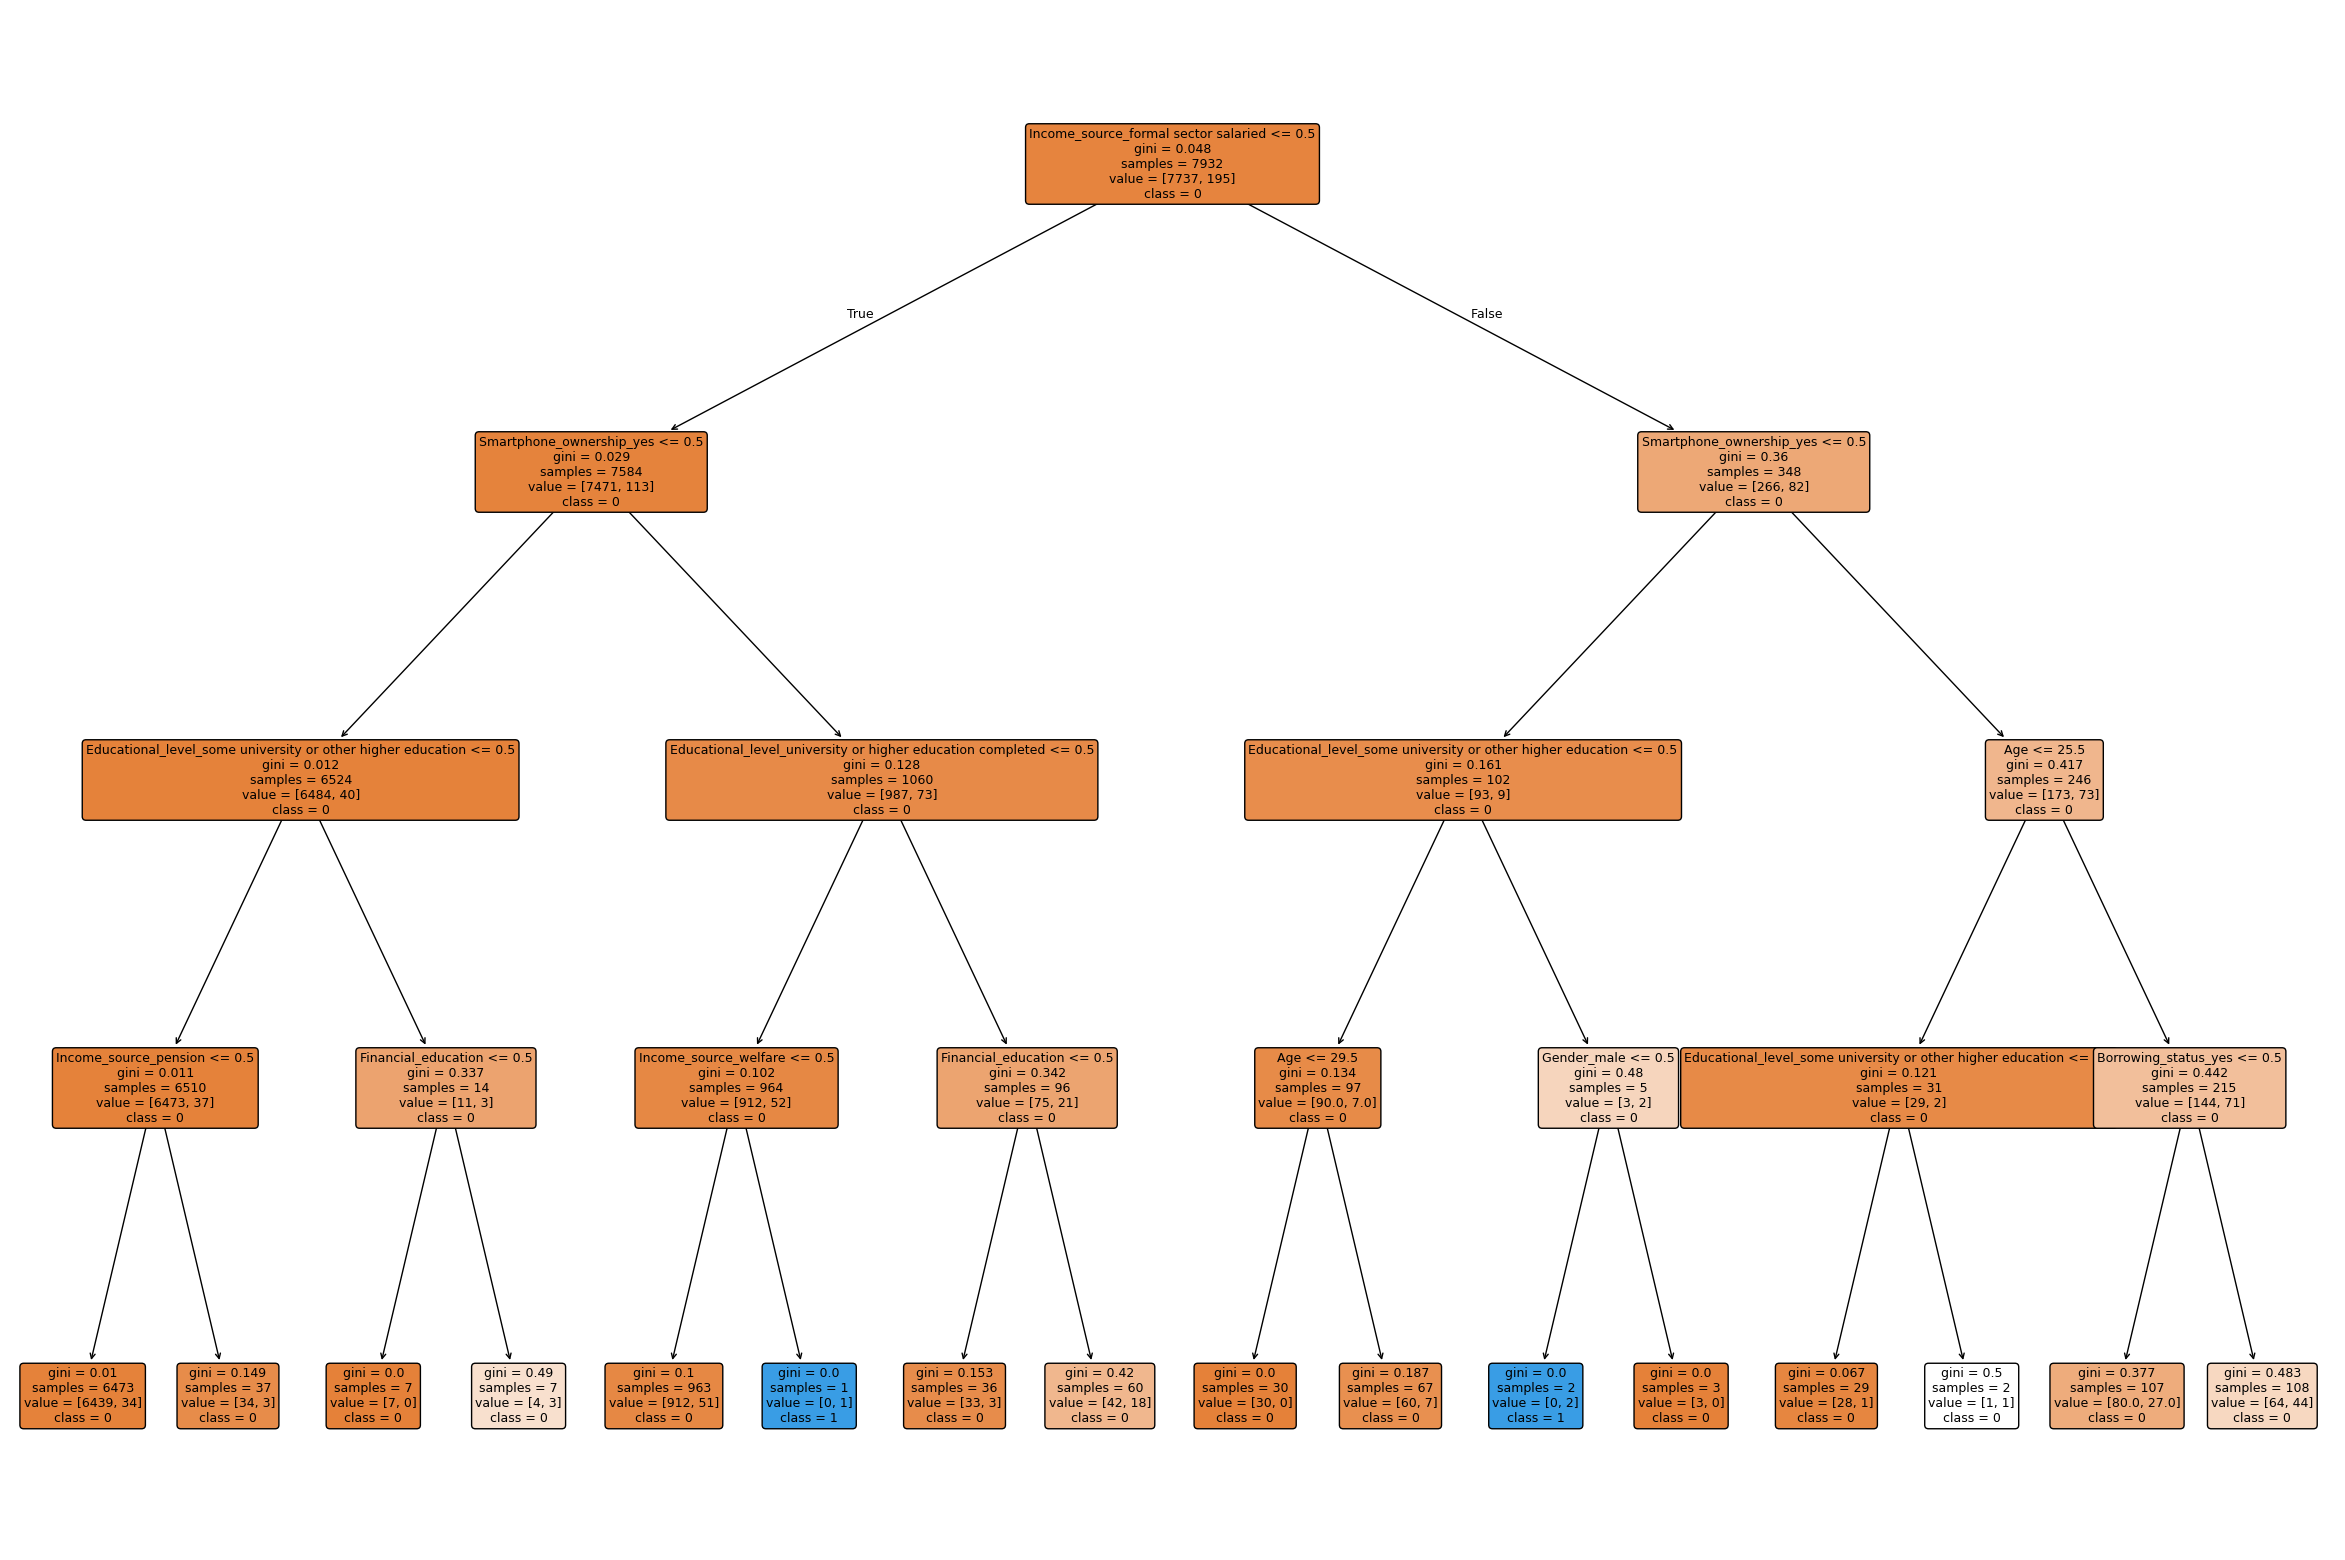

In [15]:
plt.figure(figsize=(30,20)) # 1. Increase the figure size!
plot_tree(
    tree, 
    feature_names=X.columns,    # 2. Shows 'Income' instead of 'X[0]'
    class_names=['0', '1'],     # 3. Shows the target labels
    filled=True,                # 4. Colors the nodes by class
    rounded=True,               # 5. Makes it look cleaner
    fontsize=9                 # 6. Makes the text readable
)
plt.show()

#### **5. Evaluate the Results**

Now we see how well it performs on unseen data.

In [16]:
# Evaluation
# Calculate accuracy
acc = accuracy_score(y_test, y_pred)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate precision
precision = precision_score(y_test, y_pred)

# Calculate recall
recall = recall_score(y_test, y_pred)

# Print evaluation results
print(f'Accuracy: {acc:.2f}')
print('Confusion Matrix:\n', cm)
print(f'Precision: {precision:.2f}, Recall: {recall:.2f}')


Accuracy: 0.98
Confusion Matrix:
 [[1933    1]
 [  48    1]]
Precision: 0.50, Recall: 0.02


## ⚖️ **Class imbalance and The accuracy trap**

<details>
<summary>What is class imbalance. From the abover evaluation results is the model performing better?</summary>

#### 🔁 Recap from AI Wizards – Class Imbalance

In AI Wizards Session 3, you explored the concept of **Target Class Balancing**.

It was observed that:

- Some datasets contain **many more examples of one class than the other**.
- Example:  
  - 95% “No Bank Account”
  - 5% “Has Bank Account”

This situation is called **Class Imbalance**.

In Orange:
- Used *Select Rows*
- Undersampled the majority class
- Compared Confusion Matrix balance
- Observed how accuracy can be misleading

The same issue exist here as the same dataset (FinScop) is used

**📊 Model Results**

After training a Decision Tree abover, the evaluation metrics are:

Accuracy: 0.98  

Confusion Matrix:

[[1933    1]  
 [  48    1]]

Precision: 0.50  
Recall: 0.02  

**🧠 Interpreting the Confusion Matrix**

Let’s break this down:

|                | Predicted No | Predicted Yes |
|---------------|--------------|---------------|
| **Actual No**  | 1933 (TN)    | 1 (FP)        |
| **Actual Yes** | 48 (FN)      | 1 (TP)        |

What does this mean?

- The model correctly predicts almost all “No” cases.
- It predicts almost *no* “Yes” cases correctly.
- It only caught **1 out of 49 actual Yes cases**.

**🚨 The Accuracy Trap**

Accuracy = 0.98 looks amazing.

But: Recall = 0.02 → TERRIBLE.

Why?

Because the dataset is **imbalanced**.

If 97% of the data is “No”, the model can predict “No” for almost everyone and still get very high accuracy.

This is called: ***The Accuracy Trap***. High accuracy BUT Poor performance on the minority class.

In financial inclusion context:
- The minority class = people who **have bank accounts**
- Missing them might not seem critical

But imagine *fraud detection* or *disease detection*:

- Missing positive cases is extremely dangerous.

**Why Recall is so low**

Recall = TP / (TP + FN). The model is:
- Biased toward the majority class
- Learning that predicting “No” is safer
- Avoiding predicting “Yes”
</details>

***What should be done to improve model performance and evaluation results?***

The following are possible strategies can be used to overcome Target class imbalance

**Step 1: *Apply Class Weights***
- The most effective change is telling the DecisionTreeClassifier that the minority class (1) is statistically "heavier" than the majority (0).

In [17]:
# Add class_weight='balanced' to the Decision Tree Classifier
tree_balanced = DecisionTreeClassifier(
    max_depth=4, 
    criterion='gini', 
    random_state=42,
    class_weight='balanced' # This is the magic ingredient
)

tree_balanced.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

**Step 2: *Use probabilities instead of hard predictions***
- By default, .predict() uses a 50% threshold. In imbalanced data, the model might be "pretty sure" (e.g., 30% sure) someone has an account, but the code ignores it because it's not over 50%.

In [18]:
# Get probabilities instead of 0s and 1s

y_probs = tree_balanced.predict_proba(X_test)[:, 1]

# Lower the threshold to 0.3 (30%) to be more sensitive to the minority class
threshold = 0.3
y_pred_new = (y_probs >= threshold).astype(int)

**Step 3: *Evaluate with the Right Metrics***
- Since accuracy is misleading, we will use the classification_report to see the "F1-Score" and "Recall" for the minority class.

In [19]:
# STRATEGY 3: Comprehensive Evaluation
print("--- New Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_new))
print(precision_score(y_test, y_pred_new))

# Calculate recall
print(recall_score(y_test, y_pred_new))

print("\n--- Detailed Classification Report ---")
# Look specifically at the row for '1'
print(classification_report(y_test, y_pred_new))

--- New Confusion Matrix ---
[[1501  433]
 [   8   41]]
0.08649789029535865
0.8367346938775511

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.78      0.87      1934
           1       0.09      0.84      0.16        49

    accuracy                           0.78      1983
   macro avg       0.54      0.81      0.51      1983
weighted avg       0.97      0.78      0.85      1983



🔎 Interpretation

- Is Recall low?
- Is it stuck in the Accuracy Trap?
- Are false negatives high?

<details>
<summary>Compare the evaluation metrices of before and after model balancing, what is the key difference?</summary>
Here is a summary comparison table of evaluation metrics before and after model balancing

| Metric | Original Model | New Balanced Model |
|--------|----------------|-------------------|
| Accuracy | 0.98 (Fake High) | 0.78 (Realistic) |
| Recall (Class 1) | 0.02 (Terrible) | 0.84 (Excellent) |
| Precision (Class 1) | 0.50 (Rarely guessed) | 0.09 (Wide net) |

From the abover model performance improvement you can also play with the tree depth and see how the performance responses.
</details>

<details>
<summary>What are other methods to deal with Target class imbalance?</summary>

- In AI Wizards you saw other methods like *Change the training data* by either Over sample the Minority class or Undersample the Majority class
- Then used **Undersampling the majprity class** approach, in this approach you essentially "throw away" some of the majority class (0) data points until the number of samples is closer to the minority class (1)
- Here are advantages and disadvantage of this method

| Pros | Cons |
|----|----|
|**Simplicity**: Very easy to explain and implement.|**Information Loss**: You just threw away ~1,800 rows of data.|
|**Speed**: The model trains much faster on a smaller dataset.|**Bias**: You might delete ""borderline"" cases that help the model define the boundary.|
|**Balance**: No more ""Accuracy Paradox."""|**Variance**: With only 98 total samples, the model might be less stable.|
- Oversampling minority class would be best option
</detais>

## 🔄 **Cross Validation and Hyperparameter Tuning**

### **Cross Validation**

**🌿 Recap from AI Wizards**
<details>
<summary> What is Cross Validation?</summary>

In AI Wizards, you learned that:

- Training accuracy alone is not reliable.
- Test accuracy from a single split may depend on luck.
- A better strategy is to use **Cross-Validation**.

In Orange, you:

- Tuned parameters (like tree depth).
- Checked **train-CV score**.
- Compared models using cross-validation instead of just one test split.
- Selected the best model based on CV performance.

You learned an important principle:

> Cross-validation gives a more reliable estimate of how well a model will generalize to unseen data.

Cross validation concept is these even here with Python and Scikit-learn. let's implement and see if the decision tree model performance above can improve.

* **K-Fold CV:** Splits data into k equal folds. Train on k–1 folds, test on 1, and repeat so each fold is used as test once. Gives a distribution of performance; average is a robust estimate.
* **Why important:** K-Fold CV reduces variance in performance estimation and is a better gauge than a single split.
* **Hyperparameter Tuning:** We can tune model hyperparameters using GridSearchCV (an exhaustive search) with cross-validation. GridSearchCV tries all combinations of specified parameters and selects the best based on CV score.
* **Parameters to tune:** for trees – e.g. max_depth, n_estimators, learning_rate. For random forest – n_estimators, max_depth, max_features.

</details>


#### Cross-Validation with Scikit-learn
- **Stratified *K-Fold* Cross-Validation**, it ensure that the model's performance isn't just a "lucky" result of one specific data split. It forces the model to prove its Recall across different subsets

In [20]:
# Cross-validation with StratifiedKFold

# import necessary libraries for cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

***1. Initialize the model with the 'balanced' weights found successful***

In [21]:
# Initialize the model with the 'balanced' weights
dt_model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)

***2. Set up Stratified K-Fold***
   - Use 5 folds, meaning the data is split into 5 parts, and the model is trained/tested 5 different times.

<details>
<summary>What are the Key parameters for Cross-Validation (CV)? </summary>

1. `n_splits` (The "K" in K-Fold): The number of groups (folds) the data is divided into. If n_splits=5, the data is divided into 5 parts. The model trains on 4 and tests on 1. It repeats this 5 times so that every data point gets a chance to be in the "test set" exactly once.

2. `scoring`: Because of an imbalanced dataset, this is most critical parameter. The metric used to judge the model during each fold.
   - By default, CV often looks at accuracy. As discovered in previous section, accuracy is a "trap" for FinScope data.
   - Because of target class imbalance, the `scoring` should be set to 'recall', 'precision', or 'f1'.
   - scoring='recall' ensures the CV process is specifically hunting for the best way to find those bank account holders.

3. `shuffle`: A boolean (True or False) that determines if the data is mixed up before splitting.
   - If your data is sorted (e.g., all "Bank Account = Yes" people are at the bottom of the Excel sheet), the folds will be biased unless you shuffle them first. Always set this to True for your case.

4. `stratify` (within `StratifiedKFold`): This ensures each fold has the same percentage of samples of each target class as the complete set.
   - Because only 2.5% of data has bank accounts, a standard KFold might accidentally create a fold with zero bank account holders. StratifiedKFold prevents this by forcing that 2.5% ratio into every single fold.

5. `n_jobs`: The number of CPU cores to use for the calculation.
   - Setting n_jobs=-1 tells a computer to use all available processors.
   - Since CV trains the model multiple times (e.g., 5 or 10 times), it can take a while. Running them in parallel reduces waiting time.

</details>

In [22]:
# Set up Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

***3. Calculate Cross-Validation scores for RECALL***
   - Prioritize recall because the target class is imbalance.

In [23]:
# Calculate recall scores for each fold
recall_scores = cross_val_score(dt_model, X_train, y_train, cv=skf, scoring='recall')


In [24]:
# Print the recall scores for each fold and the mean recall with standard deviation
print("Fold Recall Scores:", recall_scores)
print("Mean CV Recall:", recall_scores.mean())
print("Std Dev:", recall_scores.std())

Fold Recall Scores: [0.74358974 0.76923077 0.74358974 0.84615385 0.66666667]
Mean CV Recall: 0.7538461538461538
Std Dev: 0.057563959796522186


#### **Tuning**

- Controll model complexity by limiting the depth and the leaf to prevent overfitting


In [25]:
tree_tuned = DecisionTreeClassifier(
    max_depth=4, 
    criterion='gini', 
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced' # This is the magic ingredient
)

tree_tuned.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

- Cross-Validate the tuned model

In [26]:
cv_recall_tuned = cross_val_score(
    tree_tuned,
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)

print("Tuned Model Mean CV Recall:", cv_recall_tuned.mean())

Tuned Model Mean CV Recall: 0.7743589743589744


- Compare the out of Tuned model recal with the base line recall, is there a difference?
- Visualize the tree of tuned model

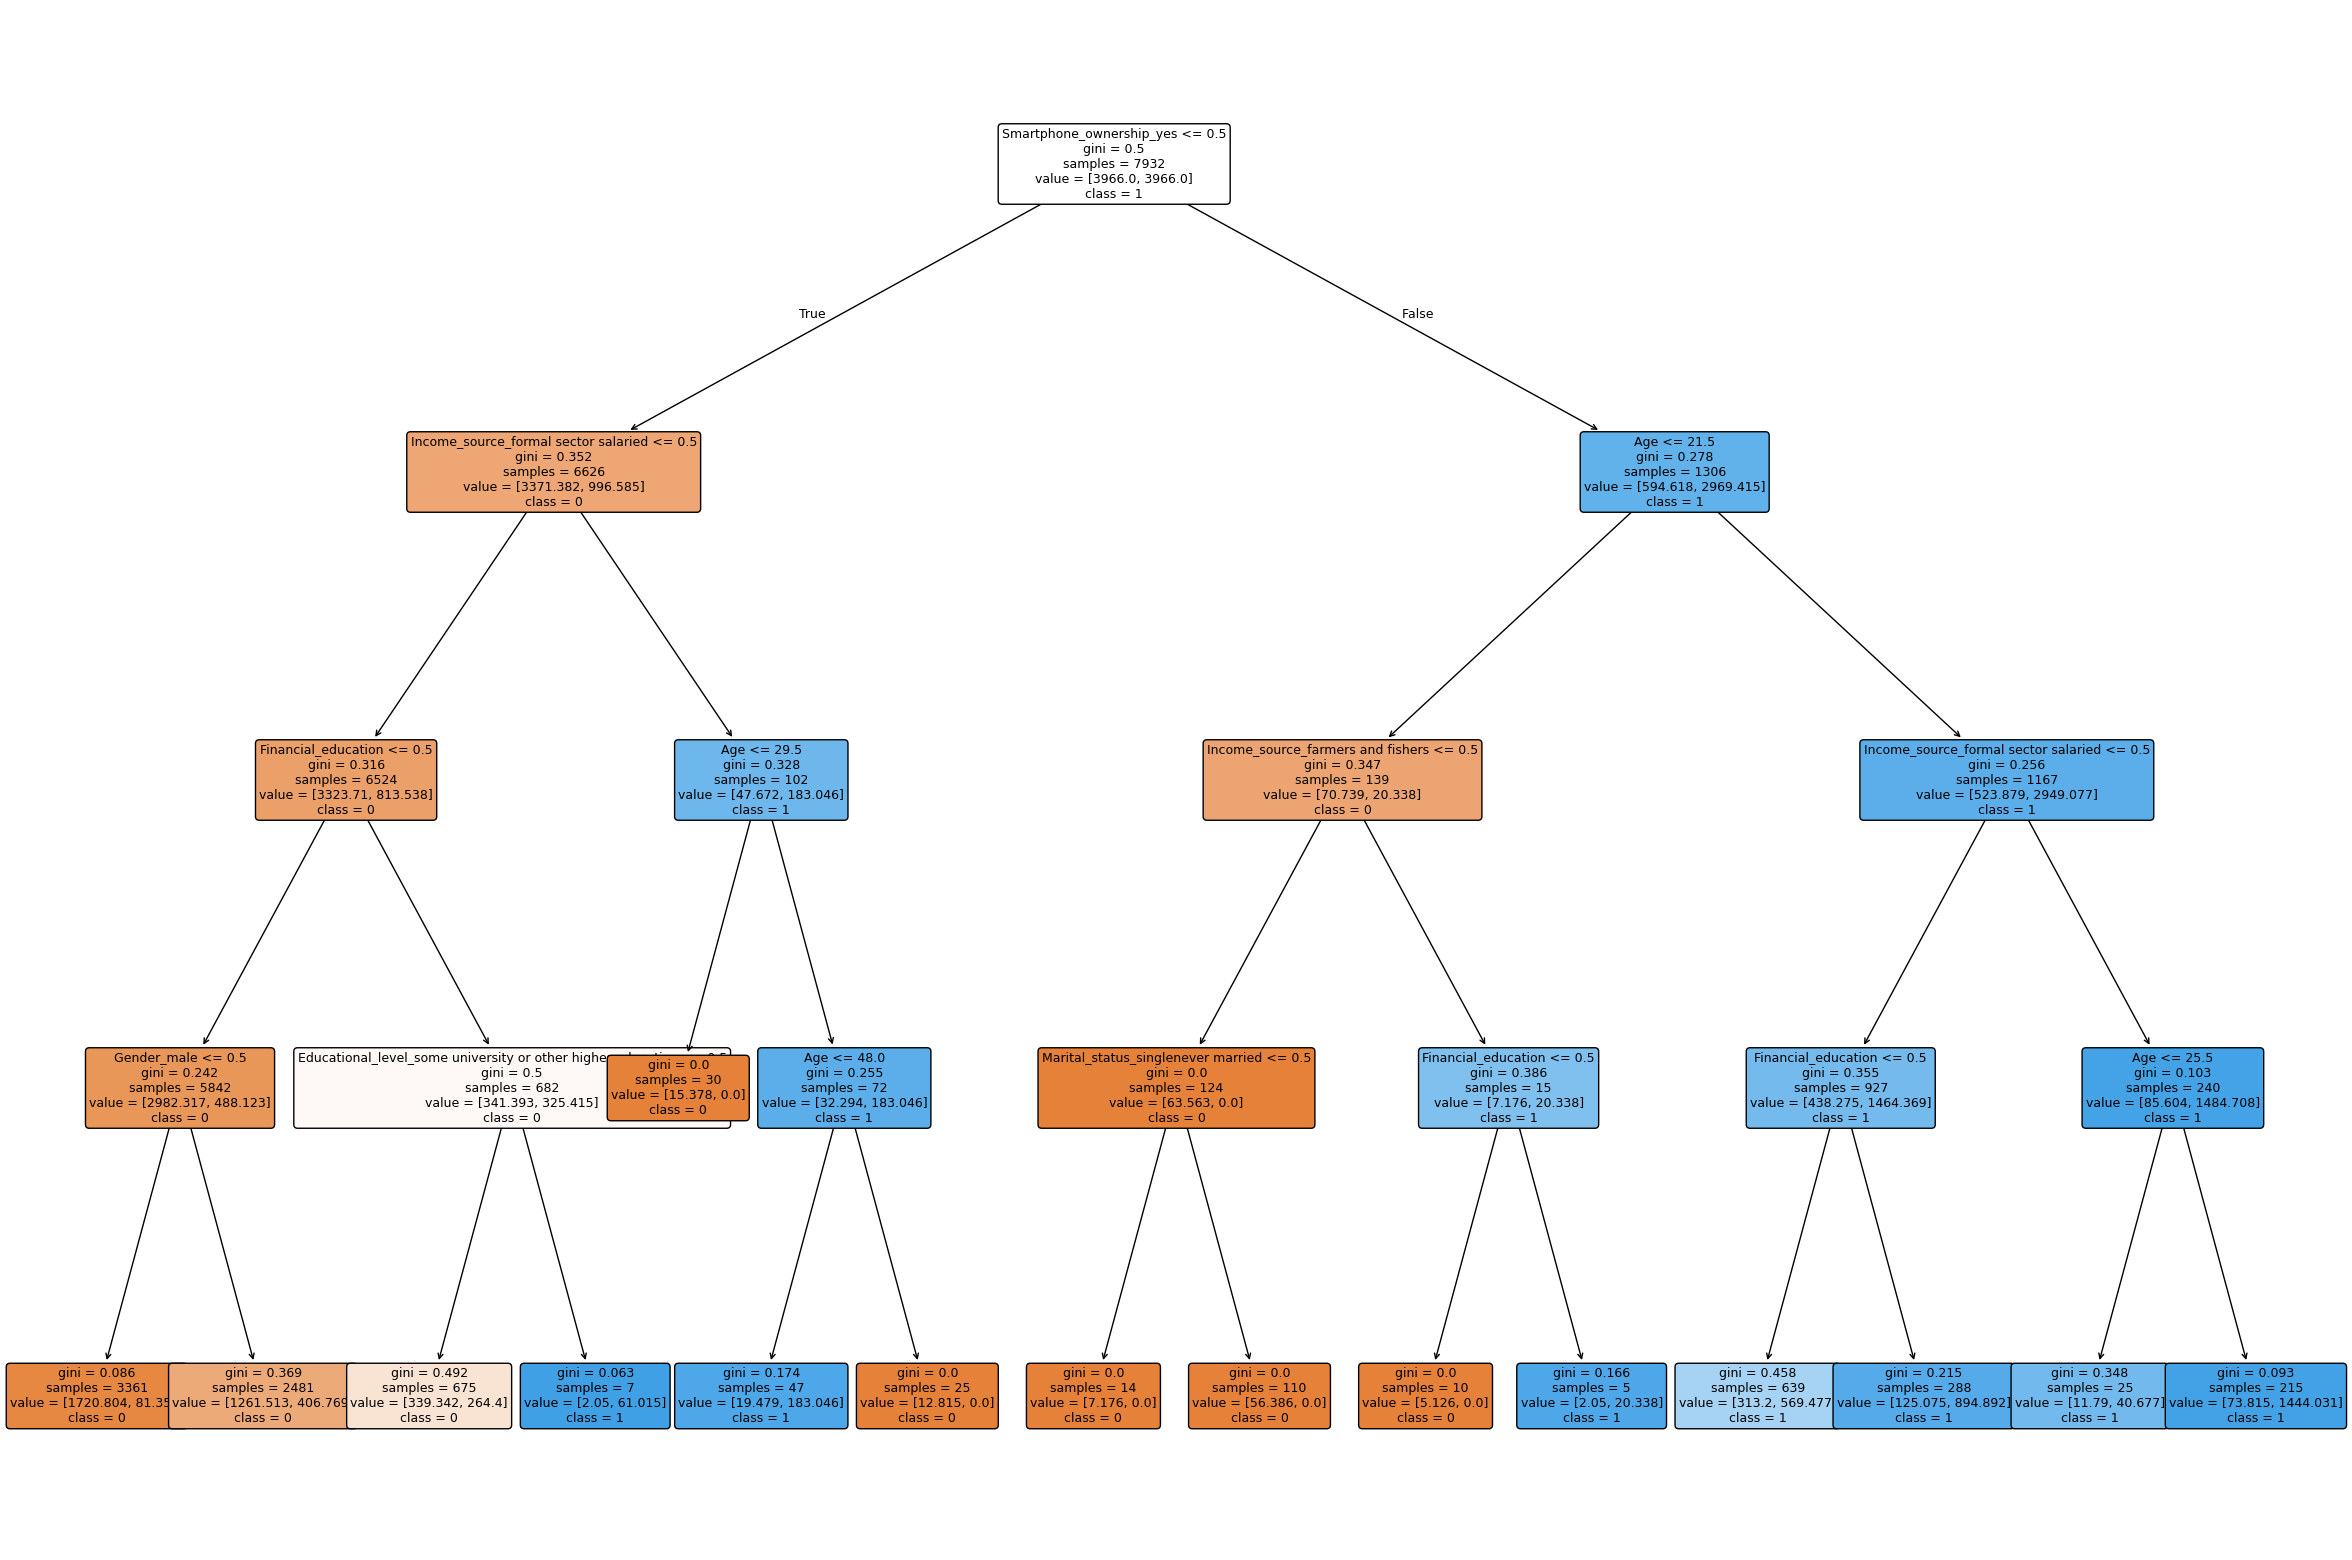

In [27]:
plt.figure(figsize=(30,20)) # 1. Increase the figure size!
plot_tree(
    tree_tuned, 
    feature_names=X.columns,    # 2. Shows 'Income' instead of 'X[0]'
    class_names=['0', '1'],     # 3. Shows the target labels
    filled=True,                # 4. Colors the nodes by class
    rounded=True,               # 5. Makes it look cleaner
    fontsize=9                 # 6. Makes the text readable
)
plt.show()

- Perform final evauation on test set, after selecting best configulation using CV

In [28]:
tree_tuned.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [29]:
final_predictions = tree_tuned.predict(X_test)

In [30]:
print("Final Test Recall:", recall_score(y_test, final_predictions))
print("Final Test Accuracy:", accuracy_score(y_test, final_predictions))
print("Final Confusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

Final Test Recall: 0.7142857142857143
Final Test Accuracy: 0.8598083711548159
Final Confusion Matrix:
[[1670  264]
 [  14   35]]


- Discuss the insights from model evaluation metrics on test data (X_test)
     - Between ***Recall*** and ***Accuracy*** which should be taken into consideration and why?

## 🔍 **GridSearchCV — Systematic Hyperparameter Tuning**

<details>
<summary> 🧠 What Is GridSearchCV?</summary>

GridSearchCV:

1. Takes a model.
2. Takes a grid of hyperparameter values.
3. Tries **every possible combination**.
4. Evaluates each using k-fold cross-validation.
5. Selects the best combination automatically.

It combines:

✔ Cross-validation  
✔ Hyperparameter tuning  
✔ Model selection  

All in one tool.

</details>

#### ***Step 1: Initialize the base model with class weights***

- Keep `class_weight` = `'balanced'` constant


In [31]:
# Initialize the base model with class weights
# Keep class_weight='balanced' constant

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

#### ***Step 2: Define the "Hyperparameter Grid"***

Think of this as a menu of options you want the computer to test for you.

- `max_depth`: Prevents the tree from growing too deep and overfitting.

- `min_samples_leaf`: Ensures each "leaf" has enough data to be statistically significant.

- `criterion`: The math used to decide where to split ('gini' vs 'entropy').

In [32]:
# Define the parameter grid (the combinations to test)
param_grid = {
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

#### ***Step 3: Set up the Cross-Validation strategy***


In [33]:
# Set up the Cross-Validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### ***Step 4: Initialize GridSearchCV***

Since the data is imbalanced, you must not use accuracy. 
- Use `scoring='f1'`for great balance
- Use `scoring='recall'` if you only care about catching every '1'

In [34]:
# Initialize GridSearchCV
# scoring = 'recall' to catching every '1'

grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=skf,
    scoring='recall', 
    n_jobs=-1 # Use all CPU cores for speed
)

#### ***Step 5: Run the search on the training data***
- Investigate the search after fiting the GridSearchCV with training data

In [35]:
# Run the search on the training data
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In the output above investigate the following:
 - Expand the `GridSearchCV` and check all the parameters used
 - Exapand the `best_estimator_` and observe best parameters combination when calling `DecisionTreeClassifier`
 - Expand the `DecisionTreeClassifier`, observe all parameter combination for best model performance

Explain how usefull is model tuning with GridSearchCV when compared to manual tuning

#### ***Step 6: Extract the best model***
- Extract the best model 
- Print out best parameters and best score

In [36]:
# Extract the best model
best_dt = grid_search.best_estimator_

In [37]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Recall Score: {grid_search.best_score_:.2f}")

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 20}
Best Cross-Validation Recall Score: 0.79


Compare the Recall from previous output, is there any improvement?

#### ***Final Test on Unseen Data***

In [38]:
# Final Test on Unseen Data

y_final_pred = best_dt.predict(X_test)
print("\n=== Final Report on Unseen Data ===")
print(classification_report(y_test, y_final_pred))


=== Final Report on Unseen Data ===
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1934
           1       0.11      0.69      0.19        49

    accuracy                           0.86      1983
   macro avg       0.55      0.78      0.56      1983
weighted avg       0.97      0.86      0.90      1983



<details>
<summary>What to after identification of best model from GridSearchCV?</summary>

Once you have the "Best Model" from `GridSearchCV`, you have officially finished the ***tuning phase***. Now, you move into the ***interpretation*** and ***deployment phase***. 
- You want to know why the model is making its decisions and if it is ready for the real world.

- **Here are the 4 essential steps to take after GridSearchCV:**
</details>


*1. Extract and Visualize Feature Importance*

- Now that the computer has found the best tree, you need to know which columns (features) it actually cares about. 
- Is it "Age," "Income," or "Location" that predicts having a bank account?

In [39]:
# Extract feature importances from the best estimator
importances = best_dt.feature_importances_
feature_names = X_train.columns


In [40]:
# Create a DataFrame for easy plotting
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

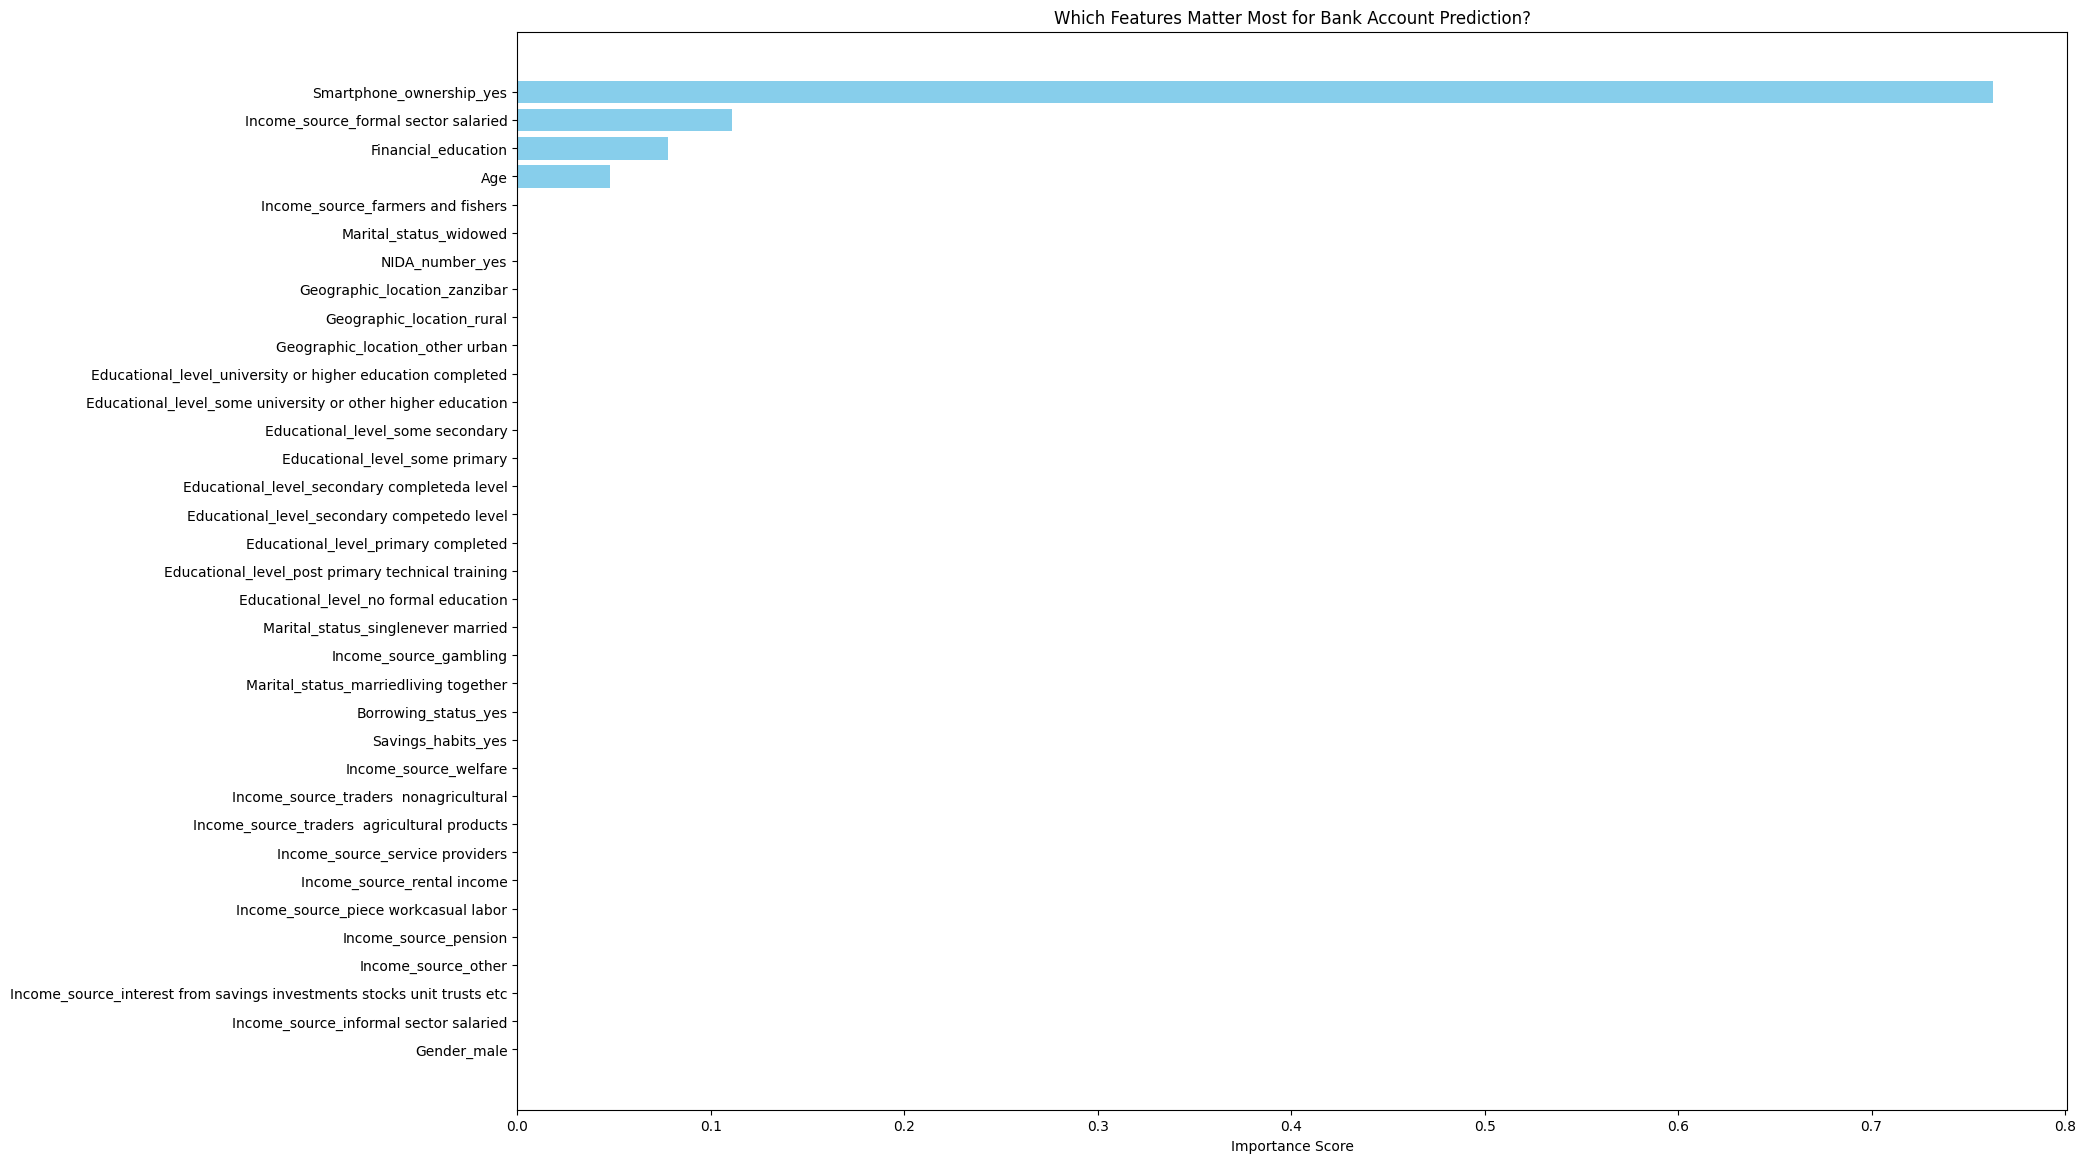

In [41]:
# Plot
plt.figure(figsize=(20, 14))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Which Features Matter Most for Bank Account Prediction?')
plt.gca().invert_yaxis()
plt.show()

*2. Compare Training vs. Testing (Checking for "Overfitting")*

- You need to make sure your model didn't just "memorize" the training data. 
- If your Training F1 is 0.95 but your Test F1 is only 0.15, your model is useless for new data.

In [42]:
train_score = best_dt.score(X_train, y_train)
test_score = best_dt.score(X_test, y_test)

print(f"Training Accuracy: {train_score:.2f}")
print(f"Testing Accuracy: {test_score:.2f}")

Training Accuracy: 0.85
Testing Accuracy: 0.86


*NOTE*:Since the dataset has imbalanced targt class, compare the **Recall of the training* set vs the *Recall of the test* set instead of accuracy. If they are within 5-10% of each other, the model is robust.

In [43]:
from sklearn.metrics import recall_score

# 1. Get predictions for both sets using the 'best' model from GridSearchCV
y_train_pred = best_dt.predict(X_train)
y_test_pred = best_dt.predict(X_test)

# 2. Calculate Recall for both (specifically for Class 1)
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

print(f"Training Recall: {train_recall:.4f}")
print(f"Testing Recall:  {test_recall:.4f}")

# 3. Calculate the 'Gap'
gap = train_recall - test_recall
print(f"Recall Gap:      {gap:.4f}")

Training Recall: 0.7949
Testing Recall:  0.6939
Recall Gap:      0.1010


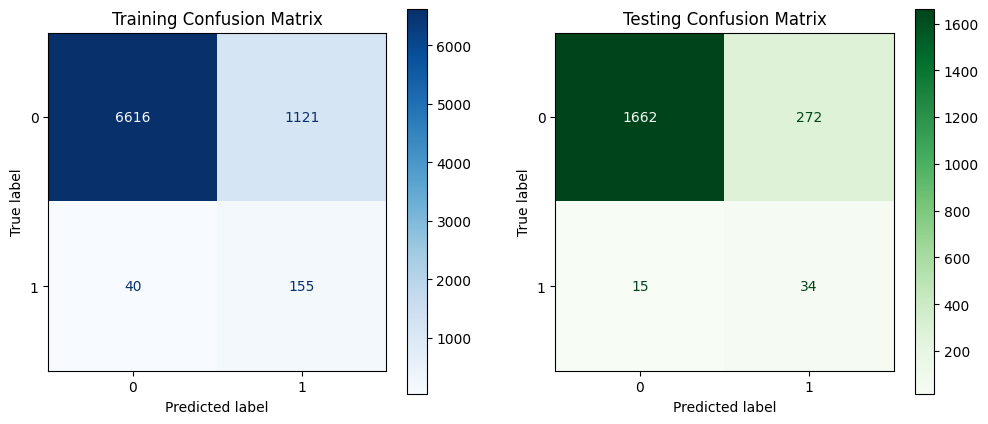

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=ax[0], cmap='Blues')
ax[0].set_title("Training Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax[1], cmap='Greens')
ax[1].set_title("Testing Confusion Matrix")

plt.show()

*3. Analyze the "Probability Distribution"*

- Since you are dealing with a 2.5% minority, the model might be "unsure" about many cases. 
- Instead of just looking at 0 or 1, look at the probabilities. 
- This helps you see if the model is confidently wrong or just barely missing.

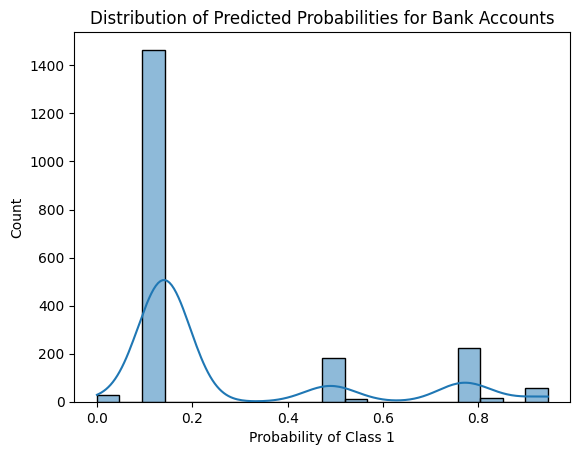

In [45]:
import seaborn as sns

y_probs = best_dt.predict_proba(X_test)[:, 1]
sns.histplot(y_probs, bins=20, kde=True)
plt.title('Distribution of Predicted Probabilities for Bank Accounts')
plt.xlabel('Probability of Class 1')
plt.show()

*4. Save the Model for Deployment*

- If you are happy with the results, you don't want to run GridSearchCV (which can take a long time) every time you want to make a prediction. 
- You should save the "Best Estimator" to a file.

In [46]:
import joblib

# Save the model to a file
joblib.dump(best_dt, 'best_bank_account_model.pkl')

# Later, you can load it in a different script:
# model = joblib.load('best_bank_account_model.pkl')

['best_bank_account_model.pkl']

**Practice Task:**
1. Build a DecisionTreeClassifier on the Adult data dataset. Experiment with parameters like max_depth or criterion.
2. Interpret the tree: which features are at the top splits? What do the leaf decisions mean?
3. Compute evaluation metrics and identify true/false positives/negatives.

**Hint:** Use DecisionTreeClassifier from scikit-learn and functions like accuracy_score, confusion_matrix, precision_score, and recall_score. Compare training vs test accuracy to spot overfitting.

## 🌲 Random Forest Ensemble (30 minutes)

**Recap:** A single decision tree can overfit. To improve stability, we use ensembles. Random Forest is an ensemble of many decision trees, each trained on a random subset of data and features. It aggregates their votes to make a prediction. This reduces variance and overfitting.

**Scenario:** Continuing the loan approval example, instead of relying on one banker’s decision tree, a microfinance officer consults many independent experts (trees), each seeing slightly different data (bagging). The final decision is by majority vote. This ensemble approach yields more accurate, robust results.



**Technical:** A Random Forest uses bagging (bootstrap aggregation): it trains each tree on a random sample of data (with replacement) and often on a random subset of features. Key points:
* Each tree is deep (unpruned), but because of averaging, the model’s overall variance is much lower than a single tree.
* Reduces overfitting: random forests typically generalize better than a single tree.
* Feature randomness (each split considers only a subset of features) decorrelates trees.
* We can extract feature importances from a random forest to see which features most influence predictions.

**Code Demo (RandomForestClassifier):** We will train RandomForestClassifier on the same data, tune number of trees (n_estimators), and compute metrics. We will display feature importances to interpret the model.

In [47]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# Train random forest
# rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
# rf.fit(X_train, y_train)
# y_pred_rf = rf.predict(X_test)

# Evaluation
# acc_rf = accuracy_score(y_test, y_pred_rf)
# cm_rf = confusion_matrix(y_test, y_pred_rf)
# precision_rf = precision_score(y_test, y_pred_rf)
# recall_rf = recall_score(y_test, y_pred_rf)
# print(f'Random Forest Accuracy: {acc_rf:.2f}')

# Feature importances
# importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
# print("Feature importances:\n", importances)

# Plot feature importances
# plt.figure(figsize=(6,4))
# sns.barplot(x=importances.values, y=importances.index)
# plt.title('Feature Importances (Random Forest)')
# plt.show()

**Practice Task:**
1. Train a RandomForestClassifier on the data. Try different n_estimators and max_depth.
2. Compare its performance (accuracy, precision, recall) to the decision tree.
3. Identify the most important features. How do they align with domain knowledge?
4. Discuss variance reduction: does the random forest overfit less than the single tree?

## ⚡ Gradient Boosting (GradientBoostingClassifier) (30 minutes)

**Recap:** We have learned bagging (Random Forest) to reduce variance. Boosting is another ensemble strategy that reduces bias by sequentially training trees.

**Scenario:** Suppose we entered a data science competition to predict credit default. We first build a simple model. Boosting allows us to iteratively improve predictions: after each tree, we focus on the mistakes of the previous models, gradually correcting errors. For example, the first tree might predict most cases correctly but miss some frauds. The next tree then tries hard on those misclassified cases, improving overall accuracy.



**Technical:** Gradient Boosting Machines (GBM) build trees one at a time; each new tree fits the residuals (errors) of the combined previous ensemble. Key points:
* It minimizes a loss function (e.g., log-loss for classification) via gradient descent, adding trees to improve performance.
* Main hyperparameters: n_estimators (number of trees), learning_rate (how much each tree contributes), max_depth (depth of each tree).
* Lower learning rate with more trees often improves performance but increases computation.
* Powerful but can overfit if too many trees or too deep. Early stopping or tuning can prevent this.

**Code Demo (GradientBoostingClassifier):** We will train GradientBoostingClassifier, tune n_estimators, learning_rate, and compare performance to previous models.

In [48]:
from sklearn.ensemble import GradientBoostingClassifier

# Train gradient boosting
# gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
# gb.fit(X_train, y_train)
# y_pred_gb = gb.predict(X_test)

# Evaluation
# acc_gb = accuracy_score(y_test, y_pred_gb)
# cm_gb = confusion_matrix(y_test, y_pred_gb)
# precision_gb = precision_score(y_test, y_pred_gb)
# recall_gb = recall_score(y_test, y_pred_gb)
# print(f'Gradient Boosting Accuracy: {acc_gb:.2f}')

**Practice Task:**
1. Fit a GradientBoostingClassifier. Experiment with n_estimators and learning_rate (e.g. try learning rates 0.01, 0.1, 0.2).
2. Use a validation set or cross_val_score to assess accuracy for each setting.
3. Compare this model’s metrics to the random forest and single tree. Which performs best on validation?
4. Watch out for overfitting: does training accuracy become much higher than test accuracy when trees are too many?

In [49]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Cross-validation scores for each model
# for model, name in [(tree, "Decision Tree"), (rf, "Random Forest"), (gb, "Gradient Boosting")]:
#     scores = cross_val_score(model, X, y, cv=5)
#     print(f"{name} CV accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

# Example GridSearch for Random Forest
# param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 5, 10]}
# grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
# grid_rf.fit(X_train, y_train)
# print("Best RF params:", grid_rf.best_params_)
# print("Best RF CV score:", grid_rf.best_score_)

# Example GridSearch for Gradient Boosting
# param_grid = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1], 'max_depth': [3,5]}
# grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
# grid_gb.fit(X_train, y_train)
# print("Best GB params:", grid_gb.best_params_)

**Practice Task:**
1. Use cross_val_score on your chosen model(s) to compute 5-fold cross-validated accuracy.
2. Perform a grid search: for example, tune n_estimators and max_depth for random forest, or learning_rate and n_estimators for boosting.
3. Record the best parameters found and the corresponding CV score.
4. Discuss how tuning affects performance and overfitting (e.g. does a deeper tree always help?).

## 🛠️ Mini Project: Build and Compare Tree Models (20 minutes)

**Scenario:** Using one of the datasets (e.g. Tanzania FinScope “has_bank_account” or Adult income), apply everything learned. Guide yourself through these steps:

**Data Preparation:**
* Load the dataset and split into features X and binary target y.
* Perform train-test split (e.g. 70% train, 30% test) with a fixed random seed.

**Train Models:**
* Train a DecisionTreeClassifier, RandomForestClassifier, and GradientBoostingClassifier on the training set (use default or simple parameters).
* Predict on the test set for each model.

**Evaluate Performance:**
* Compute accuracy, confusion matrix, precision, and recall for each model.
* Summarize results in a table for easy comparison.

**Interpretation:**
* Identify which model has the highest accuracy.
* Compare confusion matrices: which model has fewer false positives or false negatives?
* Extract feature importances from the random forest: which features matter most?

**Cross-Validation Check:**
* Use cross_val_score (5-fold) to estimate each model’s accuracy. Are the CV scores consistent with the single test accuracy?
* Discuss any differences.

**Hyperparameter Tuning:**
* Run a brief grid search (even with just a few settings) on one or two models to see if performance improves.
* Report the best parameters and any gain in accuracy.

Throughout the mini project, write Markdown notes summarizing each step and your observations. This guided exercise consolidates your skills in building, tuning, and interpreting tree-based models on real data.

## 🚀 Capstone Project: Tasks and Deliverables (25 minutes)

For the capstone project, learners will apply tree-based classification on a real-world problem and synthesize their findings. The tasks are:

**Dataset:** Choose one of the provided binary classification datasets (e.g., FinScope “has_bank_account”, UCI Adult income, or Soil quality).

**Tasks:**
1. **Data Loading and Cleaning:** Load the dataset, handle missing values or encoding as needed.
2. **Data Splitting:** Split into train and test sets (e.g. 80/20).
3. **Baseline Model (Decision Tree):** Train a DecisionTreeClassifier. Compute accuracy, confusion matrix, precision, and recall. Analyze errors (inspect false positives/negatives).
4. **Random Forest & Gradient Boosting:** Train RandomForestClassifier and GradientBoostingClassifier. Again compute evaluation metrics for each.
5. **Cross-Validation:** For each model, perform 5-fold cross-validation (use cross_val_score) and report average accuracy ± std.
6. **Hyperparameter Tuning:** Use GridSearchCV to tune key parameters for at least two models (e.g. depth and estimators for RF, learning rate for GBM). Note the best parameters and cross-validated score.
7. **Model Comparison:** Compare the models on the test set (and CV scores). Which model performs best? Consider both accuracy and overfitting risk.
8. **Write-Up:** Summarize your findings in a brief report. Discuss trade-offs observed, such as computation time vs. accuracy, and how tree depth or number of trees affected performance. Justify the final model choice.

**Deliverable:** A Jupyter notebook containing all code, results (with output) and answers to the tasks above, plus a short written summary of conclusions. Include plots (e.g. confusion matrices, feature importance bar charts) as needed to support your analysis.

By completing these tasks, learners will demonstrate mastery of tree-based classifiers, evaluation metrics, cross-validation, and hyperparameter tuning on a practical problem.